``` text 
# SHAP Explainability Analysis

1. Import libraries and project functions
2. Load cleaned data
3. Define features and CO₂ pressure targets
4. Recreate/load Random Forest models
5. SHAP analysis at 0.01 bar
6. SHAP analysis at 0.05 bar
7. SHAP analysis at 0.1 bar
8. SHAP analysis at 0.5 bar
9. SHAP analysis at 2.5 bar
10. Compare feature contributions across pressures
11. Scientific interpretation
```

In [1]:
# import libraries 
import pandas as pd  #data
import shap        #for shap
from sklearn.ensemble import RandomForestRegressor  # for model
from sklearn.model_selection  import train_test_split  # for spliting 
 

/home/susan/mof-co2-adsorption/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('/home/susan/mof-co2-adsorption/data/processed/data_clean_v2')
print(df.info())
print(df.head())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31234 entries, 0 to 31233
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   filename                  31234 non-null  object 
 1   lcd                       31234 non-null  float64
 2   pld                       31234 non-null  float64
 3   void_fraction             31234 non-null  float64
 4   surface_area_m2g          31234 non-null  float64
 5   mofid                     27706 non-null  object 
 6   CO2_uptake_0.01bar_molkg  31234 non-null  float64
 7   CO2_uptake_0.05bar_molkg  31234 non-null  float64
 8   CO2_uptake_0.1bar_molkg   31234 non-null  float64
 9   CO2_uptake_0.5bar_molkg   31234 non-null  float64
 10  CO2_uptake_2.5bar_molkg   31234 non-null  float64
dtypes: float64(9), object(2)
memory usage: 2.6+ MB
None
    filename    lcd    pld  void_fraction  surface_area_m2g  \
0     hMOF-0  11.75  10.75       0.795539            367

In [3]:
import random
import numpy as np

SEED = 12345
random.seed(SEED)
np.random.seed(SEED)
# Store the four structural features used in the relationship analysis.
feature_columns = ["lcd", "pld", "void_fraction", "surface_area_m2g"]

# Store the five CO2-uptake targets in increasing pressure order.
target_column = "CO2_uptake_0.01bar_molkg"

# Select only the required features and targets
features = df[feature_columns].copy()
target = df[target_column].copy()
# split data
# temp simply means temporary.
# X_train: 60%
# X_temp: 40%

# Shuffle the data only when we create the train/validation/test split—before standardization and before training any model.
X_train, X_temp, y_train, y_temp = train_test_split(features , target, test_size = 0.4 ,
                                                         shuffle=True,
                                                         random_state=SEED)


# Train: 60%
# Validation: 20%
# Test: 20%
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    shuffle=True,
    random_state=SEED
)
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_valid.shape, y_valid.shape)
print("Testing:", X_test.shape, y_test.shape)

print("\nMissing values in training features:")
print(X_train.isna().sum())

Training: (18740, 4) (18740,)
Validation: (6247, 4) (6247,)
Testing: (6247, 4) (6247,)

Missing values in training features:
lcd                 0
pld                 0
void_fraction       0
surface_area_m2g    0
dtype: int64


In [4]:
# Run the model for best rf at 0.01 bar

model_rf = RandomForestRegressor ( n_estimators=200,        # Start here, tune up to 300
                max_depth=None,          # Let trees grow fully first, then constrain
                min_samples_split=5,     # Default — tune later
                min_samples_leaf=4,      # Default — tune later
                random_state=SEED,
                n_jobs=-1    )         # uses all availavble CPU cores
            # Train using the origninal , non standarized features
model_rf.fit(X_train, y_train)
# 1. Create an explainer for the trained model
# build the explaination method for your trained RF using training data as rference
explainer = shap.TreeExplainer(model_rf, X_train) 

# 2. Sample up to 1,000 observations from the test set
# to make SHAP computation faster while keeping the sample reproducible
X_test_sample = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=SEED)
# 3. Calculate SHAP values for the sampled test observations
shap_values = explainer(X_test_sample)
# Yes. In your previous 0.01-bar notebook, 
# you had both lines,
#shap_values = explainer(X_test)
#  but they are doing the same calculation on different amounts of data:

Background dataset has 18740 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=18740 when initializing the masker.
100%|===================| 995/1000 [00:56<00:00]        

In [5]:
shap_values.shape

(1000, 4)

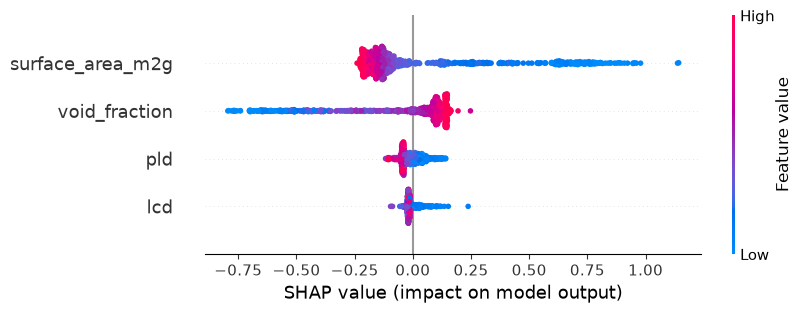

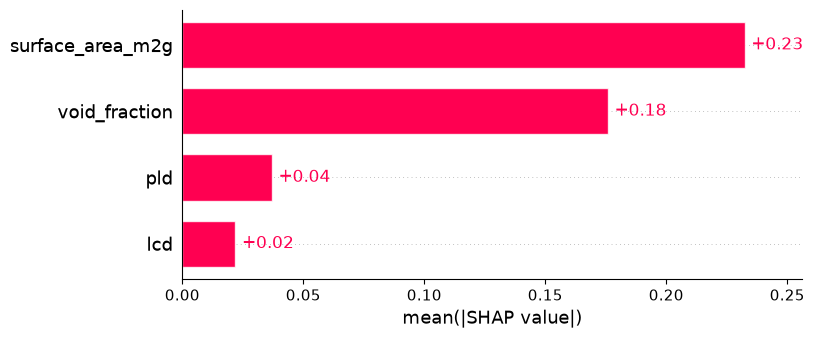

In [6]:
# 3. Global explanation — feature importance + direction
shap.plots.beeswarm(shap_values)
# 4. Global feature importance only
shap.plots.bar(shap_values)

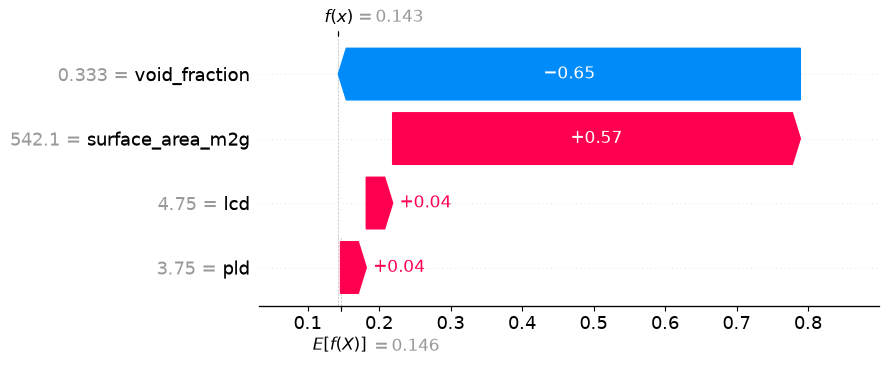

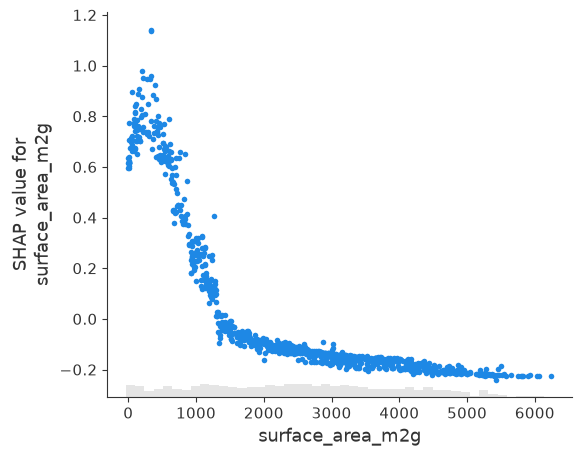

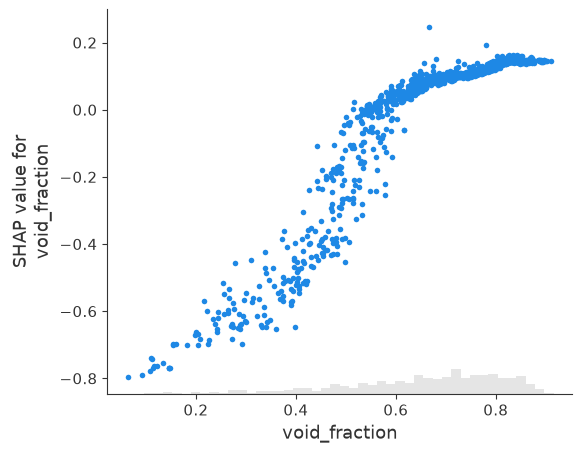

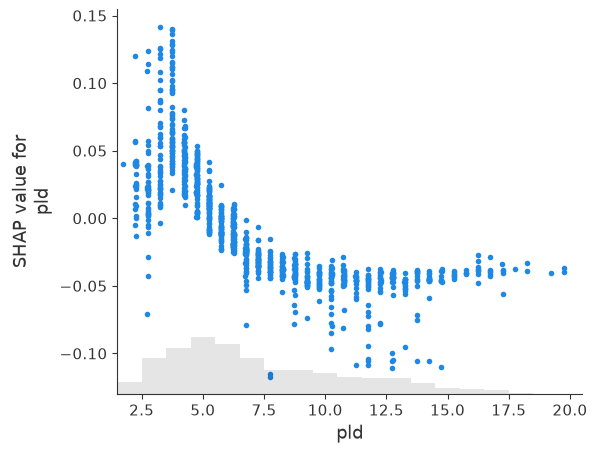

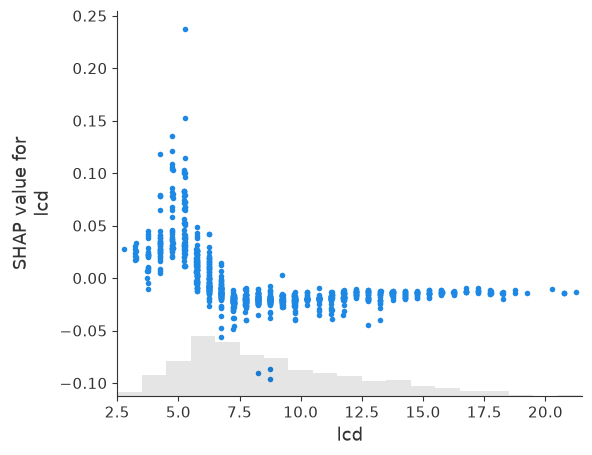

In [7]:
# 5. Explain one individual prediction
shap.plots.waterfall(shap_values[0])
# 6. Examine the effect of one feature
shap.plots.scatter(shap_values[:, "surface_area_m2g"])
shap.plots.scatter(shap_values[:, "void_fraction"])
shap.plots.scatter(shap_values[:, "pld"])
shap.plots.scatter(shap_values[:, "lcd"])




At 0.01 bar, surface area is the most influential structural feature, followed by void fraction. Increasing surface area generally shifts the model prediction toward lower CO₂ uptake, whereas lower-to-intermediate surface areas tend to increase the predicted uptake. LCD and PLD have much smaller overall impacts. For LCD, values around 4–6 Å show the strongest positive contribution, while larger LCD values generally shift the prediction slightly downward.